# Discovering a faithful one-driver complex embedding

This notebook records the constructive route to

\[
X_t=X_0+\mu t+\sigma W_t,\qquad
Z_t=Z_0\exp\!\left((\alpha+i\beta)(X_t-X_0)\right).
\]

It is deliberately different from the original Phase 3 verification
notebook. We start from design requirements, discover the log-polar
map, derive its Itô dynamics in two ways, identify the noise-rank
obstruction, and then test every claim numerically.

The notebook generates the figures and tables used by the paper. All
randomness is seeded. Analytic results are proved in the paper;
simulation is used for verification and geometric explanation.

In [1]:
from __future__ import annotations

import json
import os
import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import Normalize
import nbformat
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns
import sympy as sp


def locate_paper_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, here.parent, here / "paper"]
    candidates.extend(parent / "paper" for parent in here.parents)
    for candidate in candidates:
        if (candidate / "_quarto.yml").exists():
            return candidate
    raise RuntimeError("Could not locate paper/_quarto.yml")


PAPER_ROOT = locate_paper_root()
VECTOR_DIR = PAPER_ROOT / "figures" / "vector"
RASTER_DIR = PAPER_ROOT / "figures" / "raster"
TABLE_DIR = PAPER_ROOT / "tables"
for directory in (VECTOR_DIR, RASTER_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BASE_SEED = 20260723
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#1B1B1B",
    "gray": "#737373",
}

sns.set_theme(context="paper", style="whitegrid")
matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.bbox": "tight",
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "font.size": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)
np.set_printoptions(precision=7, suppress=True)


def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(VECTOR_DIR / f"{stem}.pdf")
    fig.savefig(RASTER_DIR / f"{stem}.png", dpi=300)
    plt.show()
    plt.close(fig)


version_rows = [
    ("Python", sys.version.split()[0]),
    ("NumPy", np.__version__),
    ("SciPy", scipy.__version__),
    ("pandas", pd.__version__),
    ("Matplotlib", matplotlib.__version__),
    ("Seaborn", sns.__version__),
    ("SymPy", sp.__version__),
    ("nbformat", nbformat.__version__),
    ("platform", platform.platform()),
    ("conda environment", os.environ.get("CONDA_DEFAULT_ENV", "unknown")),
    ("master seed", str(BASE_SEED)),
]
version_table = pd.DataFrame(version_rows, columns=["component", "version"])
version_table.to_csv(TABLE_DIR / "software_versions.csv", index=False)
version_table

,component,version
0,Python,3.12.13
1,NumPy,2.5.1
2,SciPy,1.18.0
3,pandas,3.0.3
4,Matplotlib,3.11.1
5,Seaborn,0.13.2
6,SymPy,1.14.0
7,nbformat,5.10.4
8,platform,Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43
9,conda environment,phase3-paper


## 1. Design requirements

We want a complex variable that satisfies four requirements:

1. it uses the *same single Brownian driver* as \(X\);
2. both radius and angle are stochastic;
3. the scalar state is recoverable at each time;
4. the induced complex random walk has an exact finite-step rule.

A useful starting point is not to guess \(Z\) directly. Write

\[
A_t=\log R_t=a(X_t),\qquad
\Theta_t=b(X_t),\qquad
Z_t=\exp(A_t+i\Theta_t).
\]

Any deterministic choices of \(a\) and \(b\) preserve the one-driver
constraint automatically. Injectivity can then be designed into
\(a\).

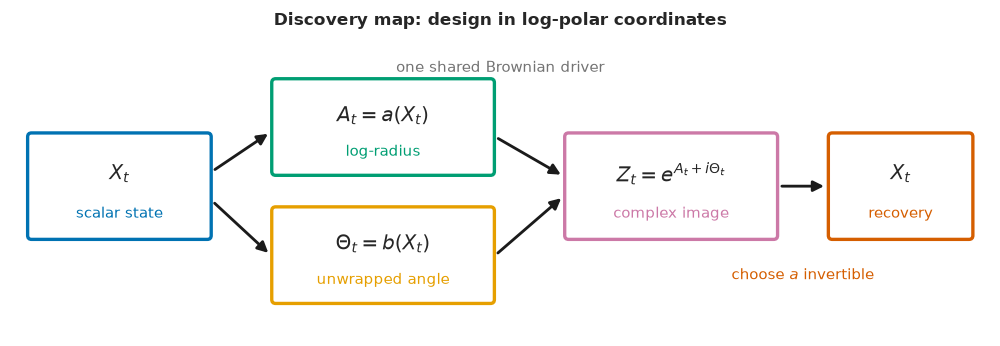

In [2]:
fig, ax = plt.subplots(figsize=(10.5, 3.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")

boxes = [
    (0.2, 1.0, 1.8, 1.0, r"$X_t$", "scalar state", COLORS["blue"]),
    (2.7, 1.65, 2.2, 0.9, r"$A_t=a(X_t)$", "log-radius", COLORS["green"]),
    (2.7, 0.35, 2.2, 0.9, r"$\Theta_t=b(X_t)$", "unwrapped angle", COLORS["orange"]),
    (5.7, 1.0, 2.1, 1.0, r"$Z_t=e^{A_t+i\Theta_t}$", "complex image", COLORS["purple"]),
    (8.4, 1.0, 1.4, 1.0, r"$X_t$", "recovery", COLORS["red"]),
]
for x, y, w, h, formula, label, color in boxes:
    box = patches.FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04",
        facecolor="white",
        edgecolor=color,
        linewidth=2,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + 0.62 * h, formula, ha="center", va="center", fontsize=12)
    ax.text(x + w / 2, y + 0.22 * h, label, ha="center", va="center", color=color)

arrow_kw = dict(arrowstyle="-|>", lw=1.7, color=COLORS["black"], mutation_scale=13)
ax.annotate("", xy=(2.65, 2.05), xytext=(2.05, 1.65), arrowprops=arrow_kw)
ax.annotate("", xy=(2.65, 0.8), xytext=(2.05, 1.35), arrowprops=arrow_kw)
ax.annotate("", xy=(5.65, 1.6), xytext=(4.95, 2.0), arrowprops=arrow_kw)
ax.annotate("", xy=(5.65, 1.4), xytext=(4.95, 0.8), arrowprops=arrow_kw)
ax.annotate("", xy=(8.35, 1.5), xytext=(7.85, 1.5), arrowprops=arrow_kw)
ax.text(5.0, 2.66, "one shared Brownian driver", ha="center", color=COLORS["gray"])
ax.text(8.1, 0.55, r"choose $a$ invertible", ha="center", color=COLORS["red"])
ax.set_title("Discovery map: design in log-polar coordinates", pad=8)
save_figure(fig, "f01_discovery_map")

## 2. The simplest smooth choice

The globally smooth affine choice

\[
a(x)=\log R_0+\alpha(x-X_0),\qquad
b(x)=\Theta_0+\beta(x-X_0)
\]

is enough. It yields

\[
Z_t=Z_0e^{c(X_t-X_0)},\qquad c=\alpha+i\beta.
\]

If \(\alpha\ne0\), the radius is strictly monotone in \(X\), giving

\[
X_t=X_0+\frac1\alpha\log\frac{R_t}{R_0}.
\]

When also \(\beta\ne0\), eliminating \(X_t-X_0\) gives the
deterministic support relation

\[
\Theta_t-\Theta_0
=\frac{\beta}{\alpha}\log\frac{R_t}{R_0},
\]

the equation of a logarithmic spiral.

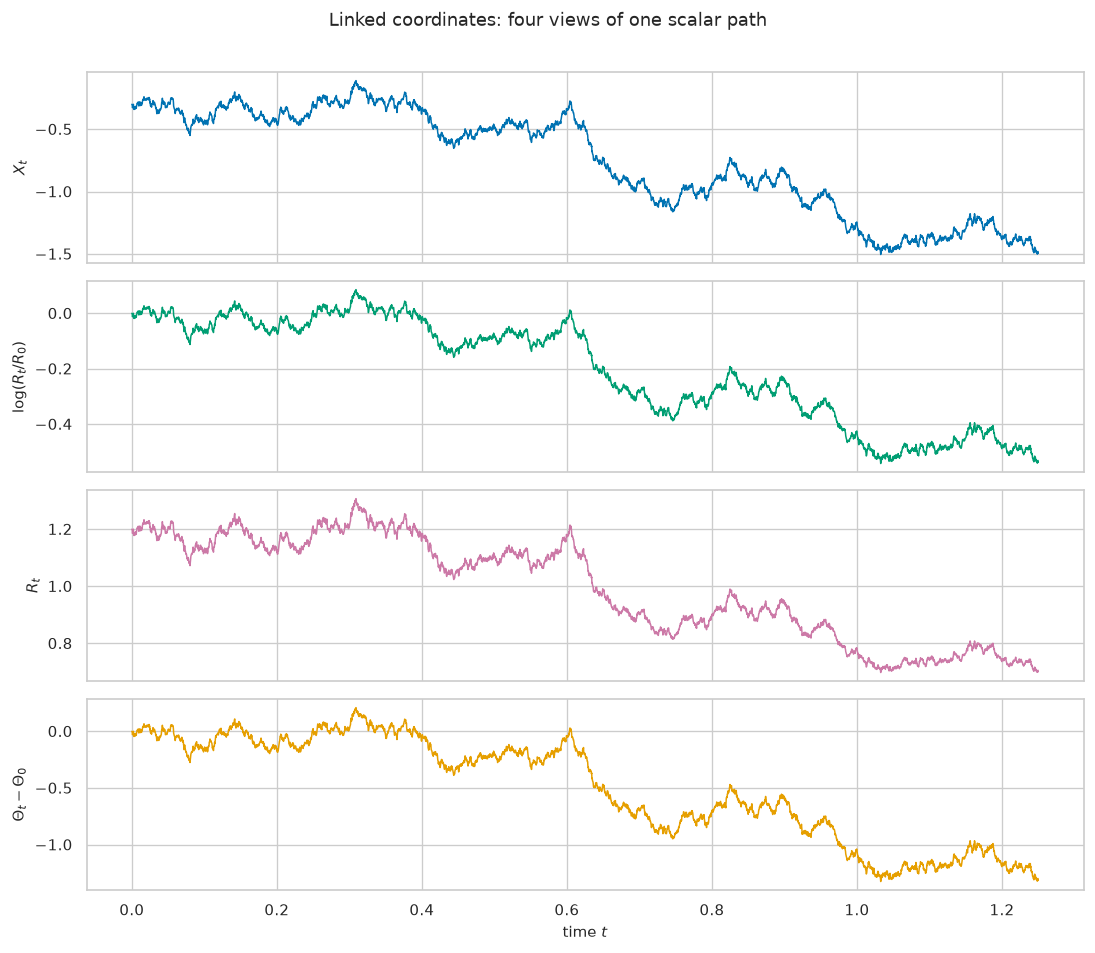

In [3]:
MU = 0.20
SIGMA = 0.65
ALPHA = 0.45
BETA = 1.10
C = ALPHA + 1j * BETA
X0 = -0.30
R0 = 1.20
THETA0 = 0.40
Z0 = R0 * np.exp(1j * THETA0)
T = 1.25

n_path = 4096
h_path = T / n_path
rng = np.random.default_rng(BASE_SEED)
dW = np.sqrt(h_path) * rng.standard_normal(n_path)
dX = MU * h_path + SIGMA * dW
t_grid = np.linspace(0.0, T, n_path + 1)
X = X0 + np.concatenate(([0.0], np.cumsum(dX)))
A = np.log(R0) + ALPHA * (X - X0)
R = np.exp(A)
theta = THETA0 + BETA * (X - X0)
Z = R * np.exp(1j * theta)

fig, axes = plt.subplots(4, 1, figsize=(9.2, 7.8), sharex=True)
series = [
    (X, r"$X_t$", COLORS["blue"]),
    (A - np.log(R0), r"$\log(R_t/R_0)$", COLORS["green"]),
    (R, r"$R_t$", COLORS["purple"]),
    (theta - THETA0, r"$\Theta_t-\Theta_0$", COLORS["orange"]),
]
for ax, (values, label, color) in zip(axes, series):
    ax.plot(t_grid, values, lw=0.9, color=color)
    ax.set_ylabel(label)
axes[-1].set_xlabel(r"time $t$")
fig.suptitle("Linked coordinates: four views of one scalar path", y=1.01)
fig.tight_layout()
save_figure(fig, "f02_linked_path")

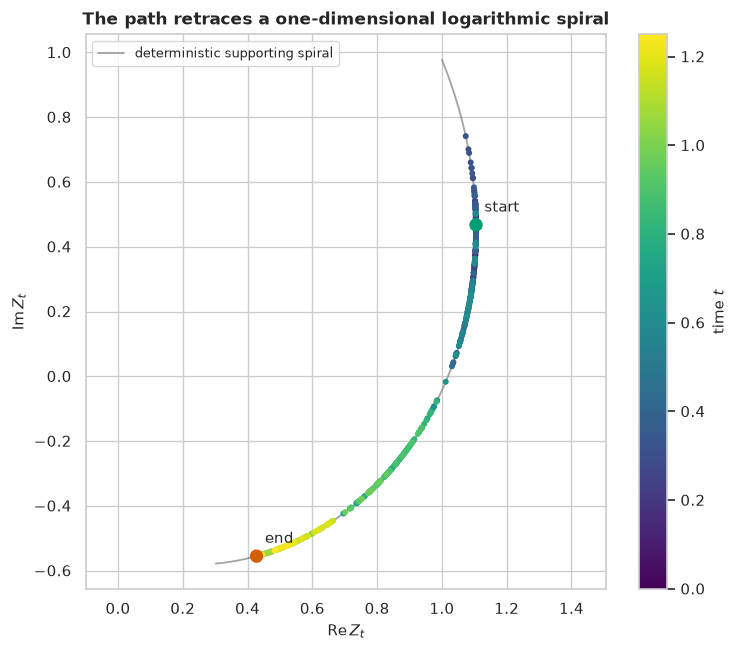

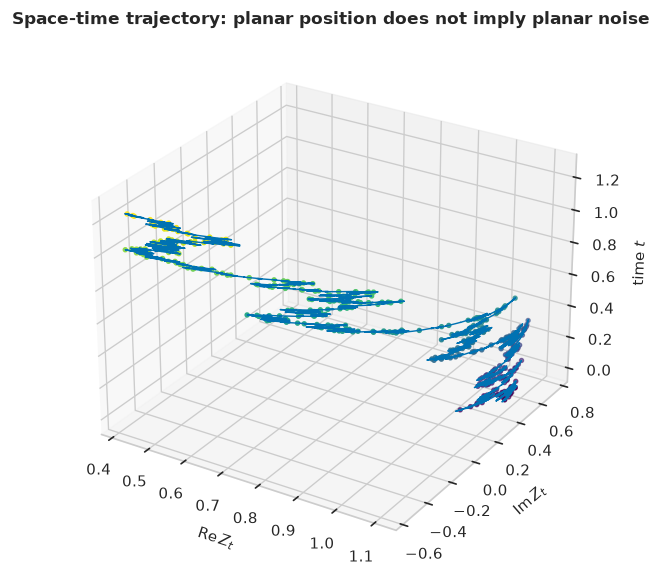

In [4]:
x_support = np.linspace(X.min() - 0.15, X.max() + 0.15, 1800)
z_support = Z0 * np.exp(C * (x_support - X0))
sample_idx = np.linspace(0, n_path, 450, dtype=int)

fig, ax = plt.subplots(figsize=(7.0, 6.0))
ax.plot(
    z_support.real,
    z_support.imag,
    color=COLORS["gray"],
    lw=1.1,
    alpha=0.65,
    label="deterministic supporting spiral",
)
points = ax.scatter(
    Z.real[sample_idx],
    Z.imag[sample_idx],
    c=t_grid[sample_idx],
    cmap="viridis",
    s=13,
    edgecolor="none",
    zorder=3,
    rasterized=True,
)
ax.scatter(
    [Z[0].real, Z[-1].real],
    [Z[0].imag, Z[-1].imag],
    c=[COLORS["green"], COLORS["red"]],
    s=52,
    zorder=4,
)
ax.annotate("start", (Z[0].real, Z[0].imag), xytext=(5, 8), textcoords="offset points")
ax.annotate("end", (Z[-1].real, Z[-1].imag), xytext=(5, 8), textcoords="offset points")
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel(r"$\operatorname{Re} Z_t$")
ax.set_ylabel(r"$\operatorname{Im} Z_t$")
ax.set_title("The path retraces a one-dimensional logarithmic spiral")
ax.legend(loc="best")
fig.colorbar(points, ax=ax, label=r"time $t$")
save_figure(fig, "f03_complex_spiral")

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(Z.real, Z.imag, t_grid, color=COLORS["blue"], lw=0.85)
ax.scatter(
    Z.real[sample_idx],
    Z.imag[sample_idx],
    t_grid[sample_idx],
    c=t_grid[sample_idx],
    cmap="viridis",
    s=6,
    rasterized=True,
)
ax.set_xlabel(r"$\operatorname{Re} Z_t$")
ax.set_ylabel(r"$\operatorname{Im} Z_t$")
ax.set_zlabel(r"time $t$")
ax.set_title("Space-time trajectory: planar position does not imply planar noise")
ax.view_init(elev=27, azim=-58)
save_figure(fig, "f04_space_time_trajectory")

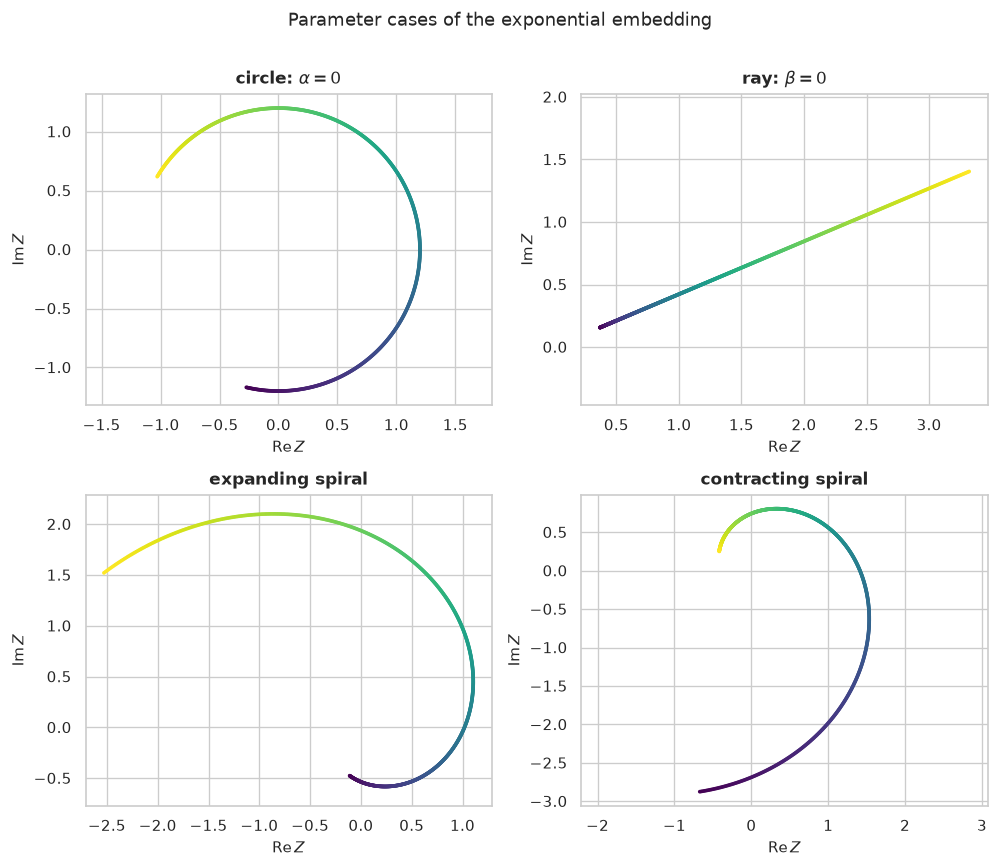

In [5]:
gallery_cases = [
    (0.0, 1.1, "circle: $\\alpha=0$"),
    (0.55, 0.0, "ray: $\\beta=0$"),
    (0.45, 1.1, "expanding spiral"),
    (-0.45, 1.1, "contracting spiral"),
]
s = np.linspace(-2.0, 2.0, 800)
fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.1))
for ax, (alpha_case, beta_case, title) in zip(axes.flat, gallery_cases):
    z_case = Z0 * np.exp((alpha_case + 1j * beta_case) * s)
    color_index = np.linspace(0.0, 1.0, len(s))
    ax.scatter(
        z_case.real,
        z_case.imag,
        c=color_index,
        cmap="viridis",
        s=5,
        edgecolor="none",
        rasterized=True,
    )
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(title)
    ax.set_xlabel(r"$\operatorname{Re} Z$")
    ax.set_ylabel(r"$\operatorname{Im} Z$")
fig.suptitle("Parameter cases of the exponential embedding", y=1.01)
fig.tight_layout()
save_figure(fig, "f05_parameter_gallery")

## 3. Exact recovery and exact random-walk steps

Every scalar grid increment

\[
\Delta X_n=\mu\,\Delta t+\sigma\,\Delta W_n
\]

induces the exact update

\[
Z_{n+1}=Z_n\exp(c\,\Delta X_n).
\]

The same scalar increment controls radial scale
\(e^{\alpha\Delta X_n}\) and rotation
\(\beta\Delta X_n\). This is an exact product identity at grid points,
not an Euler approximation.

{
  "exact_product_max_error": 6.2727600891321345e-15,
  "inverse_radius_max_error": 1.1102230246251565e-15,
  "spiral_relation_max_error": 5.273559366969494e-16
}


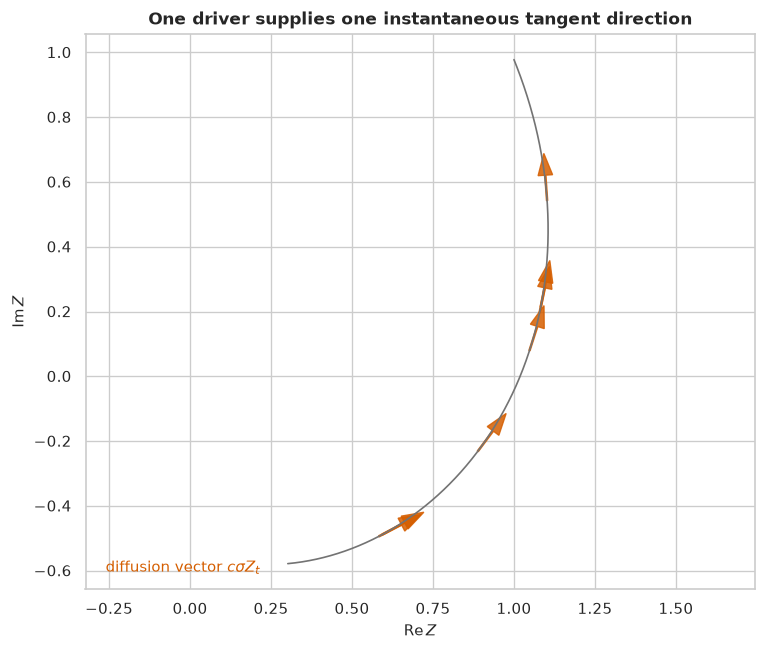

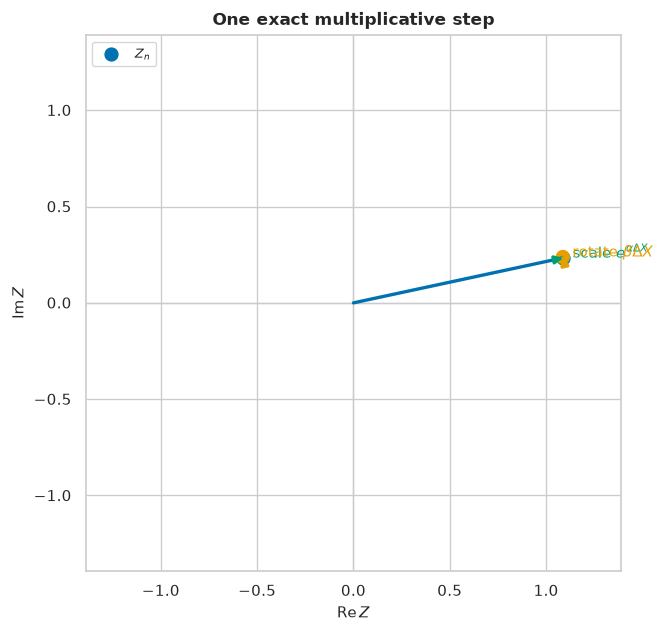

In [6]:
Z_direct = Z0 * np.exp(C * (X - X0))
Z_product = Z0 * np.concatenate(([1.0 + 0.0j], np.cumprod(np.exp(C * dX))))
X_recovered = X0 + np.log(np.abs(Z_direct) / R0) / ALPHA
spiral_residual = (
    theta - THETA0 - (BETA / ALPHA) * np.log(R / R0)
)

exactness = {
    "exact_product_max_error": float(np.max(np.abs(Z_product - Z_direct))),
    "inverse_radius_max_error": float(np.max(np.abs(X_recovered - X))),
    "spiral_relation_max_error": float(np.max(np.abs(spiral_residual))),
}
print(json.dumps(exactness, indent=2))

assert exactness["exact_product_max_error"] < 2e-12
assert exactness["inverse_radius_max_error"] < 3e-15
assert exactness["spiral_relation_max_error"] < 3e-15

support_indices = np.linspace(250, n_path - 250, 7, dtype=int)
fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.plot(z_support.real, z_support.imag, color=COLORS["gray"], lw=1.0)
for idx in support_indices:
    tangent = C * Z[idx]
    tangent /= abs(tangent)
    scale = 0.14 * np.median(np.abs(Z))
    ax.arrow(
        Z[idx].real,
        Z[idx].imag,
        scale * tangent.real,
        scale * tangent.imag,
        width=0.004,
        head_width=0.045,
        color=COLORS["red"],
        length_includes_head=True,
        alpha=0.85,
    )
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel(r"$\operatorname{Re} Z$")
ax.set_ylabel(r"$\operatorname{Im} Z$")
ax.set_title("One driver supplies one instantaneous tangent direction")
ax.text(
    0.03,
    0.03,
    r"diffusion vector $c\sigma Z_t$",
    transform=ax.transAxes,
    color=COLORS["red"],
)
save_figure(fig, "f06_local_noise_direction")

step_idx = 1730
z_before = Z[step_idx]
delta_x = dX[step_idx]
radial_only = z_before * np.exp(ALPHA * delta_x)
z_after = radial_only * np.exp(1j * BETA * delta_x)

fig, ax = plt.subplots(figsize=(7.0, 5.8))
limit = 1.25 * max(abs(z_before), abs(radial_only), abs(z_after))
ax.axhline(0, color="#cccccc", lw=0.8)
ax.axvline(0, color="#cccccc", lw=0.8)
ax.plot([0, z_before.real], [0, z_before.imag], color=COLORS["blue"], lw=2)
ax.scatter([z_before.real], [z_before.imag], color=COLORS["blue"], s=60, label=r"$Z_n$")
ax.annotate(
    "",
    xy=(radial_only.real, radial_only.imag),
    xytext=(z_before.real, z_before.imag),
    arrowprops=dict(arrowstyle="-|>", color=COLORS["green"], lw=2),
)
ax.annotate(
    "",
    xy=(z_after.real, z_after.imag),
    xytext=(radial_only.real, radial_only.imag),
    arrowprops=dict(arrowstyle="-|>", color=COLORS["orange"], lw=2),
)
ax.scatter(
    [radial_only.real, z_after.real],
    [radial_only.imag, z_after.imag],
    c=[COLORS["green"], COLORS["orange"]],
    s=60,
)
ax.text(
    radial_only.real,
    radial_only.imag,
    r"  scale $e^{\alpha\Delta X}$",
    color=COLORS["green"],
)
ax.text(
    z_after.real,
    z_after.imag,
    r"  rotate $\beta\Delta X$",
    color=COLORS["orange"],
)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal")
ax.set_xlabel(r"$\operatorname{Re} Z$")
ax.set_ylabel(r"$\operatorname{Im} Z$")
ax.set_title("One exact multiplicative step")
ax.legend(loc="upper left")
save_figure(fig, "f09_exact_multiplicative_step")

## 4. Itô dynamics, derived twice

For \(F(x)=Z_0e^{c(x-X_0)}\), \(F'=cF\) and \(F''=c^2F\).
Scalar Itô gives

\[
\frac{dZ_t}{Z_t}
=\left(c\mu+\frac12c^2\sigma^2\right)dt
+c\sigma\,dW_t.
\]

Independently, \(dA=\alpha\mu\,dt+\alpha\sigma\,dW\) and
\(d\Theta=\beta\mu\,dt+\beta\sigma\,dW\). Applying the
two-dimensional Itô formula to \(e^{A+i\Theta}\) gives the same drift:

\[
\alpha\mu+i\beta\mu
+\frac12(\alpha^2-\beta^2)\sigma^2
+i\alpha\beta\sigma^2
=c\mu+\frac12c^2\sigma^2.
\]

In [7]:
alpha_s, beta_s, mu_s, sigma_s = sp.symbols(
    "alpha beta mu sigma", real=True
)
c_s = alpha_s + sp.I * beta_s
direct_drift = sp.expand(c_s * mu_s + sp.Rational(1, 2) * c_s**2 * sigma_s**2)
polar_drift = sp.expand(
    alpha_s * mu_s
    + sp.I * beta_s * mu_s
    + sp.Rational(1, 2) * (alpha_s**2 - beta_s**2) * sigma_s**2
    + sp.I * alpha_s * beta_s * sigma_s**2
)
drift_difference = sp.simplify(direct_drift - polar_drift)
print("Direct Itô drift:", direct_drift)
print("Polar Itô drift: ", polar_drift)
print("Difference:       ", drift_difference)
assert drift_difference == 0

Direct Itô drift: alpha**2*sigma**2/2 + I*alpha*beta*sigma**2 + alpha*mu - beta**2*sigma**2/2 + I*beta*mu
Polar Itô drift:  alpha**2*sigma**2/2 + I*alpha*beta*sigma**2 + alpha*mu - beta**2*sigma**2/2 + I*beta*mu
Difference:        0


The bilinear and Hermitian complex brackets are different:

\[
d[Z,Z]_t=c^2\sigma^2Z_t^2\,dt,\qquad
d[Z,\overline{Z}]_t=|c|^2\sigma^2|Z_t|^2\,dt.
\]

The first is complex and may rotate or cancel; the second is real and
nonnegative. The next experiment compares discrete quadratic-variation
sums with their Itô-integral targets along one fixed Brownian path.

,N,h,bilinear_error,hermitian_error
0,64,0.019531,0.164957,0.141129
1,128,0.009766,0.074384,0.011564
2,256,0.004883,0.079248,0.073986
3,512,0.002441,0.020255,0.007820
4,1024,0.001221,0.021313,0.011378
5,2048,0.000610,0.016745,0.000229
6,4096,0.000305,0.009685,0.002579


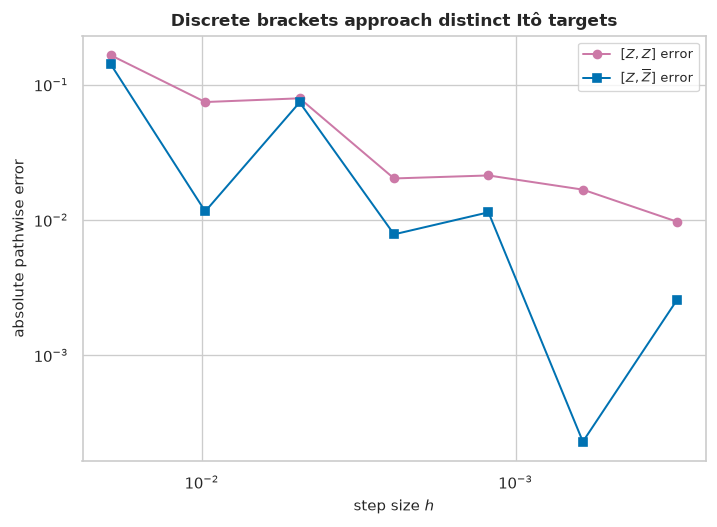

In [8]:
qv_steps = np.array([64, 128, 256, 512, 1024, 2048, 4096])
qv_rows = []
for n_steps in qv_steps:
    group = n_path // n_steps
    indices = np.arange(0, n_path + 1, group)
    z_coarse = Z[indices]
    dz_coarse = np.diff(z_coarse)
    h = T / n_steps
    qv_bilinear = np.sum(dz_coarse**2)
    qv_hermitian = np.sum(np.abs(dz_coarse) ** 2)
    target_bilinear = np.sum(C**2 * SIGMA**2 * z_coarse[:-1] ** 2 * h)
    target_hermitian = np.sum(
        abs(C) ** 2 * SIGMA**2 * np.abs(z_coarse[:-1]) ** 2 * h
    )
    qv_rows.append(
        {
            "N": n_steps,
            "h": h,
            "bilinear_error": abs(qv_bilinear - target_bilinear),
            "hermitian_error": abs(qv_hermitian - target_hermitian),
        }
    )
qv_table = pd.DataFrame(qv_rows)
qv_table.to_csv(TABLE_DIR / "quadratic_variation.csv", index=False)
display(qv_table)

assert qv_table["bilinear_error"].iloc[-1] < qv_table["bilinear_error"].iloc[0]
assert qv_table["hermitian_error"].iloc[-1] < qv_table["hermitian_error"].iloc[0]

fig, ax = plt.subplots(figsize=(6.7, 4.6))
ax.loglog(
    qv_table["h"],
    qv_table["bilinear_error"],
    "o-",
    color=COLORS["purple"],
    label=r"$[Z,Z]$ error",
)
ax.loglog(
    qv_table["h"],
    qv_table["hermitian_error"],
    "s-",
    color=COLORS["blue"],
    label=r"$[Z,\overline{Z}]$ error",
)
ax.invert_xaxis()
ax.set_xlabel(r"step size $h$")
ax.set_ylabel("absolute pathwise error")
ax.set_title("Discrete brackets approach distinct Itô targets")
ax.legend()
save_figure(fig, "f18_complex_quadratic_variation")

## 5. The covariance-rank obstruction

The log-polar diffusion vector is

\[
\sigma
\begin{pmatrix}\alpha\\\beta\end{pmatrix}.
\]

Hence

\[
\frac{d}{dt}
\begin{pmatrix}
[A,A]_t &[A,\Theta]_t\\
[\Theta,A]_t&[\Theta,\Theta]_t
\end{pmatrix}
=
\sigma^2
\begin{pmatrix}\alpha\\\beta\end{pmatrix}
\begin{pmatrix}\alpha&\beta\end{pmatrix},
\]

an outer product of rank one. More generally, if
\(F:\mathbb R\to\mathbb R^2\) is \(C^2\), then

\[
dF(X_t)=\cdots+\sigma F'(X_t)dW_t,\qquad
C_t=\sigma^2F'(X_t)F'(X_t)^\mathsf{T},
\]

so \(\operatorname{rank}C_t\le1\). This statement concerns
*instantaneous noise rank*, not the apparent dimension of a plotted
path.

,model,eigenvalue_1,eigenvalue_2,relative_matrix_error
0,one-driver log-polar,-1.387779e-16,0.595978,0.001346
1,two-driver planar control,2.497660e-01,0.250352,0.001196


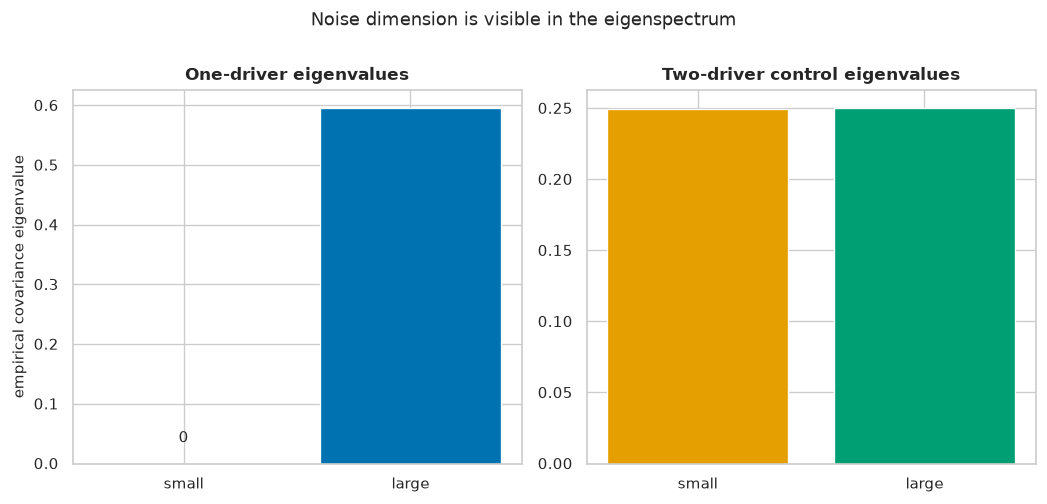

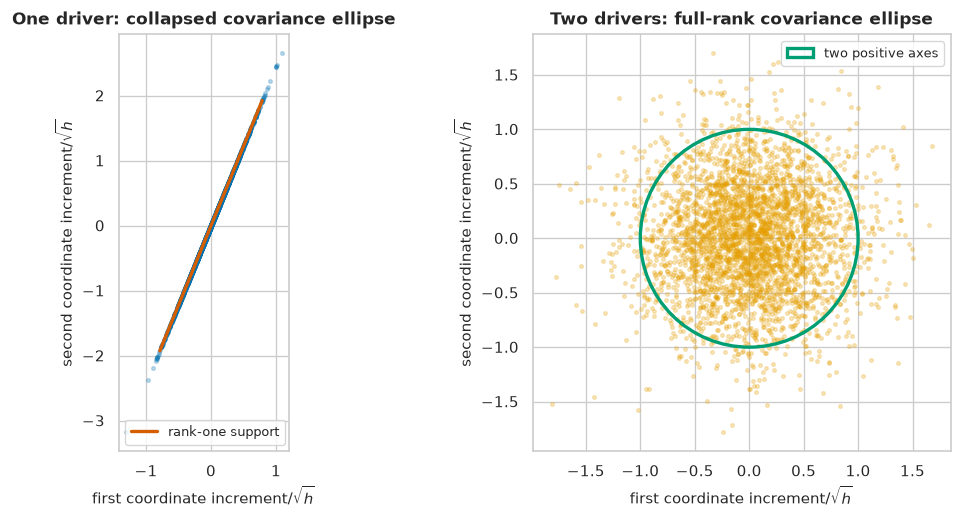

In [9]:
n_cov = 250_000
h_cov = 0.005
rng = np.random.default_rng(BASE_SEED + 2)
xi = rng.standard_normal(n_cov)
centered_scalar = SIGMA * np.sqrt(h_cov) * xi
rank1_increments = np.vstack((ALPHA * centered_scalar, BETA * centered_scalar))

empirical_rank1 = np.cov(rank1_increments, bias=True) / h_cov
theory_rank1 = SIGMA**2 * np.array(
    [[ALPHA**2, ALPHA * BETA], [ALPHA * BETA, BETA**2]]
)
eig_rank1 = np.linalg.eigvalsh(empirical_rank1)

local_radius = 1.30
planar_scale = SIGMA / local_radius
planar_increments = (
    planar_scale
    * np.sqrt(h_cov)
    * rng.standard_normal((2, n_cov))
)
empirical_rank2 = np.cov(planar_increments, bias=True) / h_cov
theory_rank2 = planar_scale**2 * np.eye(2)
eig_rank2 = np.linalg.eigvalsh(empirical_rank2)

covariance_rows = [
    {
        "model": "one-driver log-polar",
        "eigenvalue_1": eig_rank1[0],
        "eigenvalue_2": eig_rank1[1],
        "relative_matrix_error": np.linalg.norm(empirical_rank1 - theory_rank1)
        / np.linalg.norm(theory_rank1),
    },
    {
        "model": "two-driver planar control",
        "eigenvalue_1": eig_rank2[0],
        "eigenvalue_2": eig_rank2[1],
        "relative_matrix_error": np.linalg.norm(empirical_rank2 - theory_rank2)
        / np.linalg.norm(theory_rank2),
    },
]
covariance_table = pd.DataFrame(covariance_rows)
covariance_table.to_csv(TABLE_DIR / "covariance_rank.csv", index=False)
display(covariance_table)

assert covariance_table["relative_matrix_error"].max() < 0.012
assert abs(eig_rank1[0]) < 1e-12
assert eig_rank1[1] > 0.99 * SIGMA**2 * (ALPHA**2 + BETA**2)
assert eig_rank2[0] > 0.98 * planar_scale**2

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.1), sharey=False)
labels = ["small", "large"]
axes[0].bar(labels, eig_rank1, color=[COLORS["gray"], COLORS["blue"]])
axes[0].set_title("One-driver eigenvalues")
axes[0].set_ylabel("empirical covariance eigenvalue")
axes[0].text(0, max(eig_rank1) * 0.05, "0", ha="center", va="bottom")
axes[1].bar(labels, eig_rank2, color=[COLORS["orange"], COLORS["green"]])
axes[1].set_title("Two-driver control eigenvalues")
fig.suptitle("Noise dimension is visible in the eigenspectrum", y=1.01)
fig.tight_layout()
save_figure(fig, "f07_covariance_eigenspectrum")

subset = slice(0, 3500)
scale_h = np.sqrt(h_cov)
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.4))
axes[0].scatter(
    rank1_increments[0, subset] / scale_h,
    rank1_increments[1, subset] / scale_h,
    s=5,
    alpha=0.25,
    color=COLORS["blue"],
    rasterized=True,
)
direction = np.array([ALPHA, BETA])
direction = direction / np.linalg.norm(direction)
span = 3.2 * SIGMA
axes[0].plot(
    [-span * direction[0], span * direction[0]],
    [-span * direction[1], span * direction[1]],
    color=COLORS["red"],
    lw=2,
    label="rank-one support",
)
axes[0].set_title("One driver: collapsed covariance ellipse")
axes[0].legend()

axes[1].scatter(
    planar_increments[0, subset] / scale_h,
    planar_increments[1, subset] / scale_h,
    s=5,
    alpha=0.25,
    color=COLORS["orange"],
    rasterized=True,
)
circle = patches.Ellipse(
    (0, 0),
    width=4 * planar_scale,
    height=4 * planar_scale,
    fill=False,
    color=COLORS["green"],
    lw=2,
    label="two positive axes",
)
axes[1].add_patch(circle)
axes[1].set_title("Two drivers: full-rank covariance ellipse")
axes[1].legend()
for ax in axes:
    ax.set_xlabel(r"first coordinate increment$/\sqrt{h}$")
    ax.set_ylabel(r"second coordinate increment$/\sqrt{h}$")
    ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
save_figure(fig, "f08_covariance_geometry")

## 6. Exact laws and moment checks

Since \(Y_t=X_t-X_0\sim N(\mu t,\sigma^2t)\),

\[
R_t=R_0e^{\alpha Y_t}
\]

is lognormal and

\[
\mathbb E[R_t^p]
=R_0^p
\exp\!\left(
p\alpha\mu t+\frac12p^2\alpha^2\sigma^2t
\right).
\]

Complex moments are equally explicit:

\[
\mathbb E[(Z_t/Z_0)^n]
=\exp\!\left(
nc\mu t+\frac12n^2c^2\sigma^2t
\right).
\]

,quantity,component,estimate,exact,standard_error,z_score
0,E[R^1],real,1.415923,1.416649,0.001063,-0.682814
1,E[R^2],real,2.230873,2.233419,0.003636,-0.700161
2,E[(Z/Z0)^1],real,0.737468,0.737199,0.001063,0.253304
3,E[(Z/Z0)^1],imaginary,0.437494,0.438321,0.001715,-0.482263
4,E[(Z/Z0)^2],real,-0.009798,-0.010754,0.003038,0.314609
5,E[(Z/Z0)^2],imaginary,0.431580,0.431934,0.002867,-0.123696


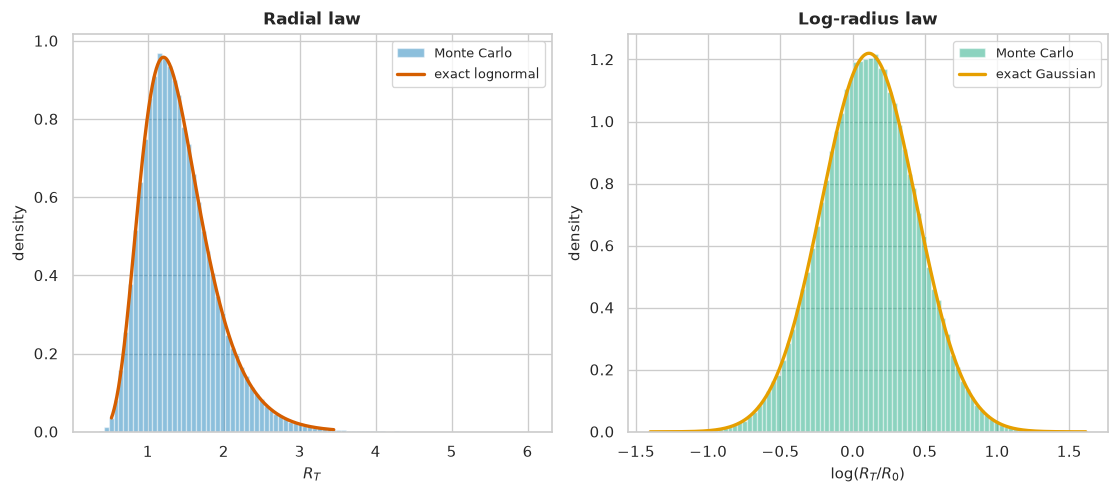

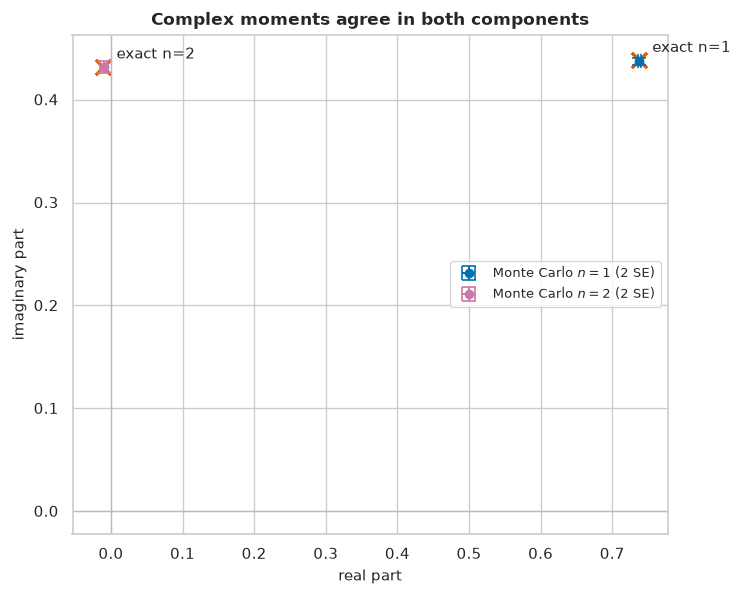

In [10]:
n_mc = 200_000
rng = np.random.default_rng(BASE_SEED + 1)
terminal_y = MU * T + SIGMA * np.sqrt(T) * rng.standard_normal(n_mc)
terminal_radius = R0 * np.exp(ALPHA * terminal_y)
terminal_ratio = np.exp(C * terminal_y)

moment_rows = []
for p in (1, 2):
    samples = terminal_radius**p
    estimate = samples.mean()
    se = samples.std(ddof=1) / np.sqrt(n_mc)
    exact = R0**p * np.exp(
        p * ALPHA * MU * T
        + 0.5 * p**2 * ALPHA**2 * SIGMA**2 * T
    )
    moment_rows.append(
        {
            "quantity": f"E[R^{p}]",
            "component": "real",
            "estimate": estimate,
            "exact": exact,
            "standard_error": se,
            "z_score": (estimate - exact) / se,
        }
    )

complex_plot_rows = []
for n in (1, 2):
    samples = terminal_ratio**n
    estimate = samples.mean()
    exact = np.exp(n * C * MU * T + 0.5 * n**2 * C**2 * SIGMA**2 * T)
    se_real = samples.real.std(ddof=1) / np.sqrt(n_mc)
    se_imag = samples.imag.std(ddof=1) / np.sqrt(n_mc)
    for component, estimate_part, exact_part, se in (
        ("real", estimate.real, exact.real, se_real),
        ("imaginary", estimate.imag, exact.imag, se_imag),
    ):
        moment_rows.append(
            {
                "quantity": f"E[(Z/Z0)^{n}]",
                "component": component,
                "estimate": estimate_part,
                "exact": exact_part,
                "standard_error": se,
                "z_score": (estimate_part - exact_part) / se,
            }
        )
    complex_plot_rows.append((n, estimate, exact, se_real, se_imag))

moment_table = pd.DataFrame(moment_rows)
moment_table.to_csv(TABLE_DIR / "moment_validation.csv", index=False)
display(moment_table)
assert moment_table["z_score"].abs().max() < 4.5

shape = abs(ALPHA) * SIGMA * np.sqrt(T)
scale = R0 * np.exp(ALPHA * MU * T)
x_density = np.linspace(
    np.quantile(terminal_radius, 0.002),
    np.quantile(terminal_radius, 0.998),
    500,
)
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.2))
axes[0].hist(
    terminal_radius,
    bins=90,
    density=True,
    alpha=0.45,
    color=COLORS["blue"],
    rasterized=True,
    label="Monte Carlo",
)
axes[0].plot(
    x_density,
    stats.lognorm.pdf(x_density, s=shape, scale=scale),
    color=COLORS["red"],
    lw=2,
    label="exact lognormal",
)
axes[0].set_xlabel(r"$R_T$")
axes[0].set_ylabel("density")
axes[0].set_title("Radial law")
axes[0].legend()

log_radius = np.log(terminal_radius / R0)
axes[1].hist(
    log_radius,
    bins=90,
    density=True,
    alpha=0.45,
    color=COLORS["green"],
    rasterized=True,
    label="Monte Carlo",
)
x_log = np.linspace(log_radius.min(), log_radius.max(), 500)
axes[1].plot(
    x_log,
    stats.norm.pdf(
        x_log,
        loc=ALPHA * MU * T,
        scale=abs(ALPHA) * SIGMA * np.sqrt(T),
    ),
    color=COLORS["orange"],
    lw=2,
    label="exact Gaussian",
)
axes[1].set_xlabel(r"$\log(R_T/R_0)$")
axes[1].set_ylabel("density")
axes[1].set_title("Log-radius law")
axes[1].legend()
fig.tight_layout()
save_figure(fig, "f10_distribution_checks")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
for n, estimate, exact, se_real, se_imag in complex_plot_rows:
    ax.errorbar(
        estimate.real,
        estimate.imag,
        xerr=2 * se_real,
        yerr=2 * se_imag,
        fmt="o",
        capsize=4,
        color=COLORS["blue"] if n == 1 else COLORS["purple"],
        label=fr"Monte Carlo $n={n}$ (2 SE)",
    )
    ax.scatter(
        exact.real,
        exact.imag,
        marker="x",
        s=85,
        linewidth=2,
        color=COLORS["red"],
    )
    ax.annotate(f" exact n={n}", (exact.real, exact.imag), xytext=(5, 5), textcoords="offset points")
ax.axhline(0, color="#bbbbbb", lw=0.8)
ax.axvline(0, color="#bbbbbb", lw=0.8)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Complex moments agree in both components")
ax.legend()
save_figure(fig, "f11_complex_moments")

## 7. Strong convergence of Euler--Maruyama

The induced complex SDE is linear:

\[
dZ_t=\lambda Z_tdt+\nu Z_tdW_t,\quad
\lambda=c\mu+\tfrac12c^2\sigma^2,\quad
\nu=c\sigma.
\]

We couple every resolution to the same finest Brownian paths and
compare terminal Euler--Maruyama values with the exact exponential
solution. The predicted generic strong order is \(1/2\).

,N,h,mean_absolute_error,standard_error,fitted_slope
0,16,0.078125,0.150392,0.001469,0.501531
1,32,0.039062,0.106417,0.000972,0.501531
2,64,0.019531,0.075794,0.000690,0.501531
3,128,0.009766,0.052824,0.000455,0.501531
4,256,0.004883,0.037456,0.000311,0.501531
5,512,0.002441,0.026537,0.000229,0.501531


Fitted strong-convergence slope: 0.5015


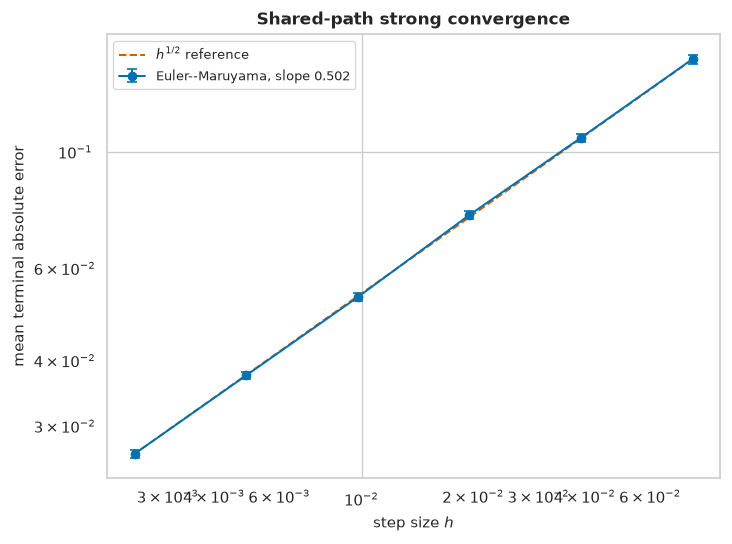

In [11]:
lambda_complex = C * MU + 0.5 * C**2 * SIGMA**2
nu_complex = C * SIGMA
n_em_paths = 10_000
n_fine = 512
rng = np.random.default_rng(BASE_SEED + 3)
dW_fine = np.sqrt(T / n_fine) * rng.standard_normal((n_em_paths, n_fine))
W_T = dW_fine.sum(axis=1)
exact_terminal = Z0 * np.exp(C * (MU * T + SIGMA * W_T))

em_steps = np.array([16, 32, 64, 128, 256, 512])
convergence_rows = []
for n_steps in em_steps:
    group = n_fine // n_steps
    coarse_dW = dW_fine.reshape(n_em_paths, n_steps, group).sum(axis=2)
    z_em = np.full(n_em_paths, Z0, dtype=complex)
    h = T / n_steps
    for k in range(n_steps):
        z_em *= 1.0 + lambda_complex * h + nu_complex * coarse_dW[:, k]
    errors = np.abs(z_em - exact_terminal)
    convergence_rows.append(
        {
            "N": n_steps,
            "h": h,
            "mean_absolute_error": errors.mean(),
            "standard_error": errors.std(ddof=1) / np.sqrt(n_em_paths),
        }
    )

convergence_table = pd.DataFrame(convergence_rows)
em_slope, em_intercept = np.polyfit(
    np.log(convergence_table["h"]),
    np.log(convergence_table["mean_absolute_error"]),
    1,
)
convergence_table["fitted_slope"] = em_slope
convergence_table.to_csv(TABLE_DIR / "strong_convergence.csv", index=False)
display(convergence_table)
print(f"Fitted strong-convergence slope: {em_slope:.4f}")

assert np.all(np.diff(convergence_table["mean_absolute_error"]) < 0)
assert 0.42 < em_slope < 0.62

fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.errorbar(
    convergence_table["h"],
    convergence_table["mean_absolute_error"],
    yerr=2 * convergence_table["standard_error"],
    fmt="o-",
    capsize=3,
    color=COLORS["blue"],
    label=f"Euler--Maruyama, slope {em_slope:.3f}",
)
reference = convergence_table["mean_absolute_error"].iloc[-1] * (
    convergence_table["h"] / convergence_table["h"].iloc[-1]
) ** 0.5
ax.plot(
    convergence_table["h"],
    reference,
    "--",
    color=COLORS["red"],
    label=r"$h^{1/2}$ reference",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"step size $h$")
ax.set_ylabel("mean terminal absolute error")
ax.set_title("Shared-path strong convergence")
ax.legend()
save_figure(fig, "f12_strong_convergence")
del dW_fine

## 8. Why the literal real-axis polar form fails globally

The direct complex image \(X_t+i0\) has radius \(|X_t|\) and angle
\(0\) or \(\pi\) away from zero. Before

\[
\tau_0=\inf\{t\ge0:X_t=0\},
\]

Itô's formula applies to \(\log|X_t|\). At a zero, the logarithm is
singular and the angle jumps between the two rays.

The correct global identity for standard Brownian motion is Tanaka's
formula

\[
|W_t|
=\int_0^t\operatorname{sgn}(W_s)\,dW_s+L_t^0,
\]

where \(L_t^0\) is symmetric local time at the origin.

Grid sign changes: 131
Discrete Tanaka identity maximum residual: 5.995e-15


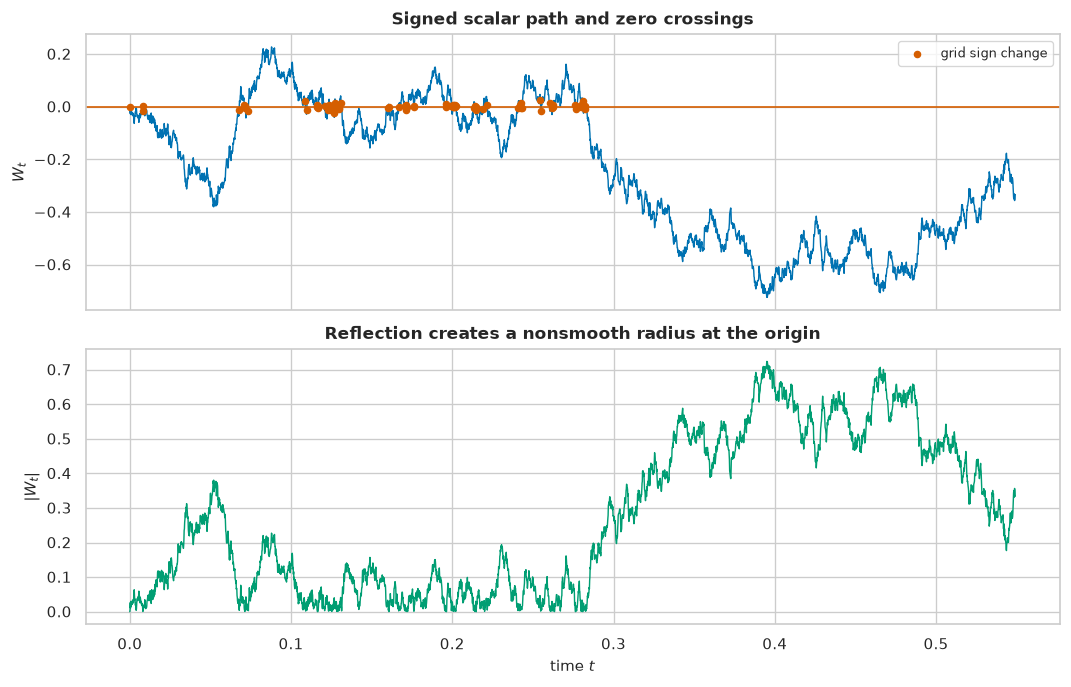

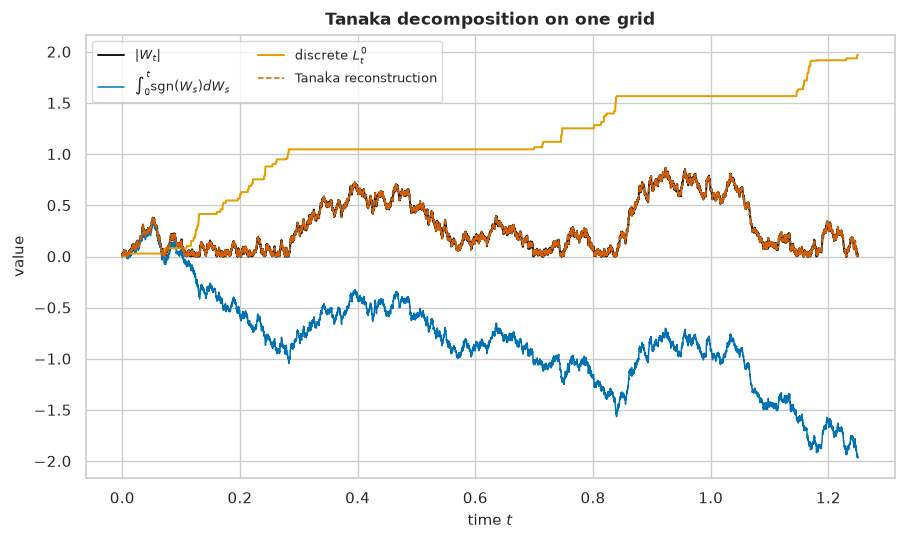

In [12]:
n_zero = 8192
h_zero = T / n_zero
rng = np.random.default_rng(BASE_SEED + 4)
dW_zero = np.sqrt(h_zero) * rng.standard_normal(n_zero)
W_zero = np.concatenate(([0.0], np.cumsum(dW_zero)))
t_zero = np.linspace(0.0, T, n_zero + 1)
sign_left = np.sign(W_zero[:-1])
ito_increments = sign_left * dW_zero
local_increments = (
    np.abs(W_zero[1:])
    - np.abs(W_zero[:-1])
    - ito_increments
)
ito_cumulative = np.concatenate(([0.0], np.cumsum(ito_increments)))
local_cumulative = np.concatenate(([0.0], np.cumsum(local_increments)))
tanaka_residual = np.max(
    np.abs(np.abs(W_zero) - ito_cumulative - local_cumulative)
)
crossing_indices = np.flatnonzero(W_zero[:-1] * W_zero[1:] <= 0)
print(f"Grid sign changes: {len(crossing_indices)}")
print(f"Discrete Tanaka identity maximum residual: {tanaka_residual:.3e}")
assert tanaka_residual < 2e-12
assert np.all(local_increments >= -2e-15)

shown = slice(0, min(3600, n_zero + 1))
fig, axes = plt.subplots(2, 1, figsize=(9.0, 5.8), sharex=True)
axes[0].plot(t_zero[shown], W_zero[shown], color=COLORS["blue"], lw=0.85)
axes[0].axhline(0, color=COLORS["red"], lw=1)
local_crossings = crossing_indices[crossing_indices < shown.stop]
axes[0].scatter(
    t_zero[local_crossings],
    W_zero[local_crossings],
    color=COLORS["red"],
    s=14,
    zorder=3,
    label="grid sign change",
)
axes[0].set_ylabel(r"$W_t$")
axes[0].set_title("Signed scalar path and zero crossings")
axes[0].legend()
axes[1].plot(
    t_zero[shown],
    np.abs(W_zero[shown]),
    color=COLORS["green"],
    lw=0.85,
)
axes[1].set_ylabel(r"$|W_t|$")
axes[1].set_xlabel(r"time $t$")
axes[1].set_title("Reflection creates a nonsmooth radius at the origin")
fig.tight_layout()
save_figure(fig, "f13_zero_crossing_anatomy")

fig, ax = plt.subplots(figsize=(8.7, 4.8))
ax.plot(t_zero, np.abs(W_zero), color=COLORS["black"], lw=1.2, label=r"$|W_t|$")
ax.plot(
    t_zero,
    ito_cumulative,
    color=COLORS["blue"],
    lw=0.9,
    label=r"$\int_0^t\operatorname{sgn}(W_s)dW_s$",
)
ax.plot(
    t_zero,
    local_cumulative,
    color=COLORS["orange"],
    lw=1.2,
    label=r"discrete $L_t^0$",
)
ax.plot(
    t_zero,
    ito_cumulative + local_cumulative,
    "--",
    color=COLORS["red"],
    lw=0.9,
    label="Tanaka reconstruction",
)
ax.set_xlabel(r"time $t$")
ax.set_ylabel("value")
ax.set_title("Tanaka decomposition on one grid")
ax.legend(ncol=2)
save_figure(fig, "f14_tanaka_decomposition")

,N,h,epsilon,discrete_mean,discrete_standard_error,occupation_mean,occupation_standard_error,identity_max_error,exact_mean,occupation_absolute_error,discrete_z_score
0,128,0.009766,0.157179,0.895332,0.008669,0.832549,0.007049,2.817191e-15,0.892062,0.059513,0.377197
1,512,0.002441,0.111142,0.882717,0.008718,0.834180,0.007474,7.105427e-15,0.892062,0.057882,-1.071947
2,2048,0.000610,0.078590,0.884203,0.008678,0.845796,0.007779,1.065814e-14,0.892062,0.046266,-0.905644
3,8192,0.000153,0.055571,0.893896,0.008822,0.868905,0.008181,1.998401e-14,0.892062,0.023157,0.207868


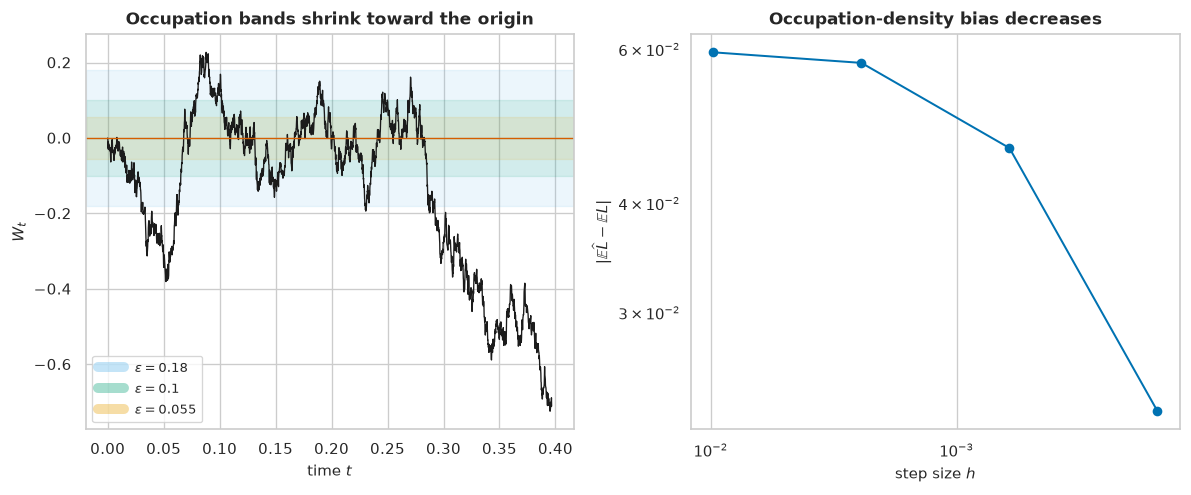

In [13]:
tanaka_steps = np.array([128, 512, 2048, 8192])
n_tanaka_paths = 6_000
exact_local_mean = np.sqrt(2.0 * T / np.pi)
tanaka_rows = []

for n_steps in tanaka_steps:
    h = T / n_steps
    epsilon = 0.5 * h**0.25
    rng = np.random.default_rng(BASE_SEED + 10 + int(n_steps))
    x = np.zeros(n_tanaka_paths)
    ito_sum = np.zeros(n_tanaka_paths)
    local_discrete = np.zeros(n_tanaka_paths)
    occupation_time = np.zeros(n_tanaka_paths)

    for _ in range(n_steps):
        sign_x = np.sign(x)
        occupation_time += (np.abs(x) < epsilon) * h
        dx = np.sqrt(h) * rng.standard_normal(n_tanaka_paths)
        x_next = x + dx
        ito_sum += sign_x * dx
        local_discrete += np.abs(x_next) - np.abs(x) - sign_x * dx
        x = x_next

    local_occupation = occupation_time / (2.0 * epsilon)
    identity_error = np.max(np.abs(np.abs(x) - ito_sum - local_discrete))
    tanaka_rows.append(
        {
            "N": n_steps,
            "h": h,
            "epsilon": epsilon,
            "discrete_mean": local_discrete.mean(),
            "discrete_standard_error": local_discrete.std(ddof=1)
            / np.sqrt(n_tanaka_paths),
            "occupation_mean": local_occupation.mean(),
            "occupation_standard_error": local_occupation.std(ddof=1)
            / np.sqrt(n_tanaka_paths),
            "identity_max_error": identity_error,
        }
    )

local_time_table = pd.DataFrame(tanaka_rows)
local_time_table["exact_mean"] = exact_local_mean
local_time_table["occupation_absolute_error"] = (
    local_time_table["occupation_mean"] - exact_local_mean
).abs()
local_time_table["discrete_z_score"] = (
    local_time_table["discrete_mean"] - exact_local_mean
) / local_time_table["discrete_standard_error"]
local_time_table.to_csv(TABLE_DIR / "local_time.csv", index=False)
display(local_time_table)

assert local_time_table["identity_max_error"].max() < 2e-12
assert local_time_table["discrete_z_score"].abs().max() < 4.5
assert local_time_table["occupation_absolute_error"].iloc[-1] < 0.06
assert (
    local_time_table["occupation_absolute_error"].iloc[-1]
    < 0.78 * local_time_table["occupation_absolute_error"].iloc[0]
)

eps_values = [0.18, 0.10, 0.055]
segment = slice(0, min(2600, n_zero + 1))
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(t_zero[segment], W_zero[segment], color=COLORS["black"], lw=0.8)
for epsilon, color in zip(
    eps_values, [COLORS["sky"], COLORS["green"], COLORS["orange"]]
):
    axes[0].axhspan(-epsilon, epsilon, color=color, alpha=0.11)
    axes[0].plot([], [], color=color, lw=6, alpha=0.35, label=fr"$\varepsilon={epsilon}$")
axes[0].axhline(0, color=COLORS["red"], lw=0.8)
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"$W_t$")
axes[0].set_title("Occupation bands shrink toward the origin")
axes[0].legend()

axes[1].loglog(
    local_time_table["h"],
    local_time_table["occupation_absolute_error"],
    "o-",
    color=COLORS["blue"],
)
axes[1].invert_xaxis()
axes[1].set_xlabel(r"step size $h$")
axes[1].set_ylabel(r"$|\mathbb{E}\widehat L-\mathbb{E}L|$")
axes[1].set_title("Occupation-density bias decreases")
fig.tight_layout()
save_figure(fig, "f15_occupation_density")

## 9. Representation hierarchy

The word *representation* hides several non-equivalent requirements:

- a deterministic image only needs \(Z_t=F(X_t)\);
- a state-injective embedding also permits pointwise recovery;
- pathwise recovery may use the entire lifted path, such as an
  unwrapped angle;
- equality as a planar stochastic model additionally requires the
  correct two-dimensional local covariance.

The logarithmic spiral satisfies the first three when \(\alpha\ne0\),
but cannot satisfy the fourth for a rank-two target.

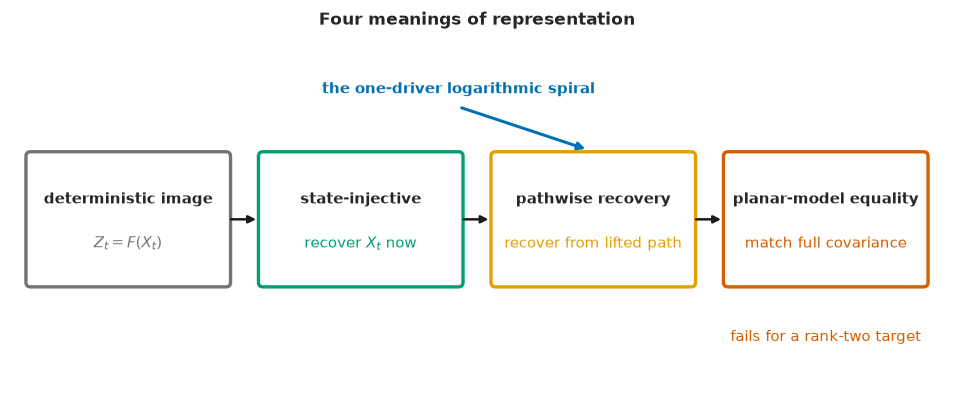

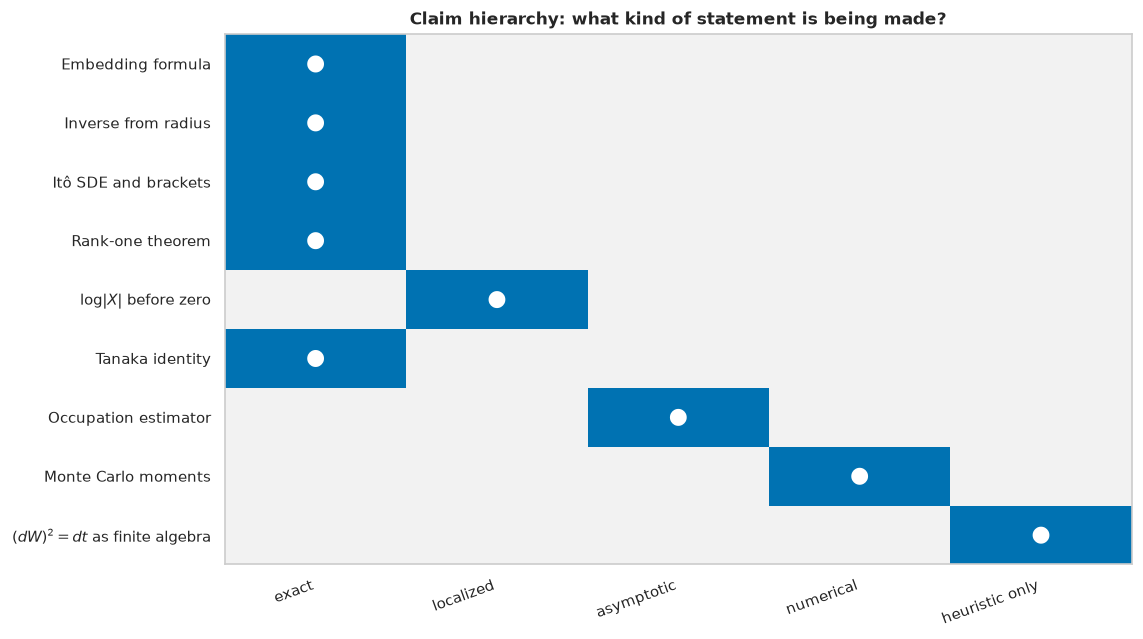

In [14]:
fig, ax = plt.subplots(figsize=(10.0, 3.9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")
hierarchy = [
    (0.2, 1.25, 2.1, "deterministic image", r"$Z_t=F(X_t)$", COLORS["gray"]),
    (2.7, 1.25, 2.1, "state-injective", "recover $X_t$ now", COLORS["green"]),
    (5.2, 1.25, 2.1, "pathwise recovery", "recover from lifted path", COLORS["orange"]),
    (7.7, 1.25, 2.1, "planar-model equality", "match full covariance", COLORS["red"]),
]
for x, y, w, title, subtitle, color in hierarchy:
    ax.add_patch(
        patches.FancyBboxPatch(
            (x, y),
            w,
            1.4,
            boxstyle="round,pad=0.05",
            facecolor="white",
            edgecolor=color,
            linewidth=2,
        )
    )
    ax.text(x + w / 2, y + 0.92, title, ha="center", va="center", weight="bold")
    ax.text(x + w / 2, y + 0.43, subtitle, ha="center", va="center", color=color)
arrow_kw = dict(arrowstyle="-|>", lw=1.5, color=COLORS["black"])
for left in (2.32, 4.82, 7.32):
    ax.annotate("", xy=(left + 0.34, 1.95), xytext=(left, 1.95), arrowprops=arrow_kw)
ax.text(
    4.8,
    3.35,
    "the one-driver logarithmic spiral",
    ha="center",
    weight="bold",
    color=COLORS["blue"],
)
ax.annotate(
    "",
    xy=(6.2, 2.72),
    xytext=(4.8, 3.2),
    arrowprops=dict(arrowstyle="-|>", color=COLORS["blue"], lw=1.8),
)
ax.text(
    8.75,
    0.6,
    "fails for a rank-two target",
    ha="center",
    color=COLORS["red"],
)
ax.set_title("Four meanings of representation")
save_figure(fig, "f16_representation_taxonomy")

claim_rows = [
    ("Embedding formula", "exact", 0),
    ("Inverse from radius", "exact", 0),
    ("Itô SDE and brackets", "exact", 0),
    ("Rank-one theorem", "exact", 0),
    (r"$\log|X|$ before zero", "localized", 1),
    ("Tanaka identity", "exact", 0),
    ("Occupation estimator", "asymptotic", 2),
    ("Monte Carlo moments", "numerical", 3),
    (r"$(dW)^2=dt$ as finite algebra", "heuristic only", 4),
]
categories = ["exact", "localized", "asymptotic", "numerical", "heuristic only"]
matrix = np.zeros((len(claim_rows), len(categories)))
for row_index, (_, _, category_index) in enumerate(claim_rows):
    matrix[row_index, category_index] = 1
cmap = matplotlib.colors.ListedColormap(["#f2f2f2", COLORS["blue"]])
fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(np.arange(len(categories)), categories, rotation=20, ha="right")
ax.set_yticks(
    np.arange(len(claim_rows)),
    [row[0] for row in claim_rows],
)
for row_index, (_, label, category_index) in enumerate(claim_rows):
    ax.text(
        category_index,
        row_index,
        "●",
        ha="center",
        va="center",
        color="white",
        fontsize=13,
    )
ax.set_title("Claim hierarchy: what kind of statement is being made?")
ax.grid(False)
fig.tight_layout()
save_figure(fig, "f17_claim_hierarchy")

## 10. Reproducible summary

The construction solves the design problem without changing the
original noise dimension:

\[
\boxed{
Z_t=Z_0e^{(\alpha+i\beta)(X_t-X_0)},\qquad
\frac{dZ_t}{Z_t}
=
\left[
(\alpha+i\beta)\mu
+\frac12(\alpha+i\beta)^2\sigma^2
\right]dt
+(\alpha+i\beta)\sigma\,dW_t.}
\]

Radius and angle are both stochastic, the radius recovers \(X_t\),
and the exact discrete walk is multiplicative. Their perfect local
coupling is the key structural fact: two visible coordinates do not
create two Brownian directions.

The mnemonic \((dW)^2=dt\) refers to a quadratic-variation limit. It
is not an algebraic square root of time and is not the stochastic
analogue of \(i^2=-1\). The role of \(i\) here is geometric rotation;
the Itô correction comes from quadratic variation.

In [15]:
summary = {
    "parameters": {
        "mu": MU,
        "sigma": SIGMA,
        "alpha": ALPHA,
        "beta": BETA,
        "X0": X0,
        "R0": R0,
        "theta0": THETA0,
        "T": T,
        "master_seed": BASE_SEED,
    },
    "exactness": exactness,
    "covariance": covariance_rows,
    "strong_convergence_slope": float(em_slope),
    "local_time_exact_mean": float(exact_local_mean),
    "local_time_finest_occupation_mean": float(
        local_time_table["occupation_mean"].iloc[-1]
    ),
    "tanaka_path_max_residual": float(tanaka_residual),
    "figure_count": len(list(VECTOR_DIR.glob("f*.pdf"))),
}
with (TABLE_DIR / "numerical_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)
with (TABLE_DIR / "exactness.json").open("w", encoding="utf-8") as handle:
    json.dump(exactness, handle, indent=2)

print(json.dumps(summary, indent=2))
assert summary["figure_count"] >= 17

{
  "parameters": {
    "mu": 0.2,
    "sigma": 0.65,
    "alpha": 0.45,
    "beta": 1.1,
    "X0": -0.3,
    "R0": 1.2,
    "theta0": 0.4,
    "T": 1.25,
    "master_seed": 20260723
  },
  "exactness": {
    "exact_product_max_error": 6.2727600891321345e-15,
    "inverse_radius_max_error": 1.1102230246251565e-15,
    "spiral_relation_max_error": 5.273559366969494e-16
  },
  "covariance": [
    {
      "model": "one-driver log-polar",
      "eigenvalue_1": -1.3877787807814457e-16,
      "eigenvalue_2": 0.5959779016059853,
      "relative_matrix_error": 0.001346135445801706
    },
    {
      "model": "two-driver planar control",
      "eigenvalue_1": 0.2497659718490787,
      "eigenvalue_2": 0.25035200092391635,
      "relative_matrix_error": 0.001195571247100207
    }
  ],
  "strong_convergence_slope": 0.5015310910600802,
  "local_time_exact_mean": 0.8920620580763856,
  "local_time_finest_occupation_mean": 0.8689047556166085,
  "tanaka_path_max_residual": 5.995204332975845e-15,
  "fig